In [4]:
# Cow Health Neural Network Classifier
# ------------------------------------------------------
# 1. Load libraries and dataset
#!pip install scikit-learn
!pip install tensorflow


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import plot_model

# Load dataset
df = pd.read_csv("fake_cow_dataset_binary_health.csv")

# ------------------------------------------------------
# 2. Initial data exploration
print("Data Head:")
print(df.head())
print("\nData Shape:", df.shape)
print("\nClass Distribution:")
print(df['health'].value_counts())

# ------------------------------------------------------
# 3. Feature selection
# Add Stress Index and Movement × Eating Interaction to the X DataFrame

df['stress_index'] = (df['heartrate'] * df['temperature']) / (df['rumination'] + 1)
df['movement_eating_combo'] = df['movement'] + '_' + df['eating']

X = df.drop(columns=['health', 'id'])
y = df['health']



print("\nPredictor Columns:")
print(X.columns.tolist())
print("\nTarget:")
print(y.name)

# ------------------------------------------------------
# 4. Preprocessing pipeline
# Updated numeric and categorical features lists
numeric_features = ['weight', 'temperature', 'rumination', 'heartrate', 'stress_index']
categorical_features = ['movement', 'eating', 'sociability', 'monitor_status', 'movement_eating_combo']

# Preprocessing pipeline (standardize numeric and one-hot encode categorical)
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(), categorical_features)
])

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# ------------------------------------------------------
# 5. Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# ------------------------------------------------------
# 6. Apply preprocessing to input features
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# ------------------------------------------------------
# 7. Build neural network model
# model = Sequential([
#     Dense(64, activation='relu', input_shape=(X_train_processed.shape[1],)),
#     Dropout(0.2),
#     Dense(32, activation='relu'),
#     Dense(4, activation='softmax')
# ])

from tensorflow.keras.layers import BatchNormalization, LeakyReLU

model = Sequential([
    Dense(128),
    BatchNormalization(),
    LeakyReLU(),
    Dropout(0.3),
    Dense(64),
    LeakyReLU(),
    Dense(2, activation='softmax')
])


model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

# ------------------------------------------------------
# 8. Train the model
history = model.fit(X_train_processed, y_train, 
                    validation_split=0.2,
                    epochs=25,
                    batch_size=128,
                    verbose=0)

# ------------------------------------------------------
# 9. Evaluate the model
y_pred = model.predict(X_test_processed)
y_pred_classes = np.argmax(y_pred, axis=1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_classes, target_names=label_encoder.classes_))

print("\nConfusion Matrix:")
#conf_matrix = confusion_matrix(y_test, y_pred_classes)
# Desired order of classes
class_labels = ['healthy', 'needs attention']
# Confusion matrix with correct label order
conf_matrix = confusion_matrix(y_test, y_pred_classes, labels=[label_encoder.transform([c])[0] for c in class_labels])
#Plot it
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


# sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
# plt.xlabel("Predicted")
# plt.ylabel("Actual")
# plt.title("Confusion Matrix")
# plt.show()

# ------------------------------------------------------
# 10. Plot training history
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Model Accuracy over Epochs')
plt.legend()
plt.show()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Model Loss over Epochs')
plt.legend()
plt.show()


  Using cached tensorboard-2.19.0-py3-none-any.whl.metadata (1.8 kB)
  Using cached keras-3.9.2-py3-none-any.whl.metadata (6.1 kB)
  Using cached numpy-2.0.2-cp39-cp39-win_amd64.whl.metadata (59 kB)
  Using cached ml_dtypes-0.5.1-cp39-cp39-win_amd64.whl.metadata (22 kB)
Using cached keras-3.9.2-py3-none-any.whl (1.3 MB)
Using cached ml_dtypes-0.5.1-cp39-cp39-win_amd64.whl (209 kB)
Using cached numpy-2.0.2-cp39-cp39-win_amd64.whl (15.9 MB)
Using cached tensorboard-2.19.0-py3-none-any.whl (5.5 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.23.5
    Uninstalling numpy-1.23.5:
      Successfully uninstalled numpy-1.23.5
  Attempting uninstall: ml-dtypes
    Found existing installation: ml-dtypes 0.3.2
    Uninstalling ml-dtypes-0.3.2:
      Successfully uninstalled ml-dtypes-0.3.2
  Attempting uninstall: tensorboard
    Found existing installation: tensorboard 2.12.3
    Uninstalling tensorboard-2.12.3:
      Successfully uninstalled tensorboard-2.12.3
  Attempt

  You can safely remove it manually.


ImportError: cannot import name 'execute_fn_for_device' from 'tensorflow.python.ops.control_flow_ops' (C:\Users\malji\anaconda3\envs\nyctaxi\lib\site-packages\tensorflow\python\ops\control_flow_ops.py)

In [ ]:
pip install tensorflowjs



In [ ]:
model.export('my_cow_model')  # this is the new way to save a SavedModel in Keras 3.x


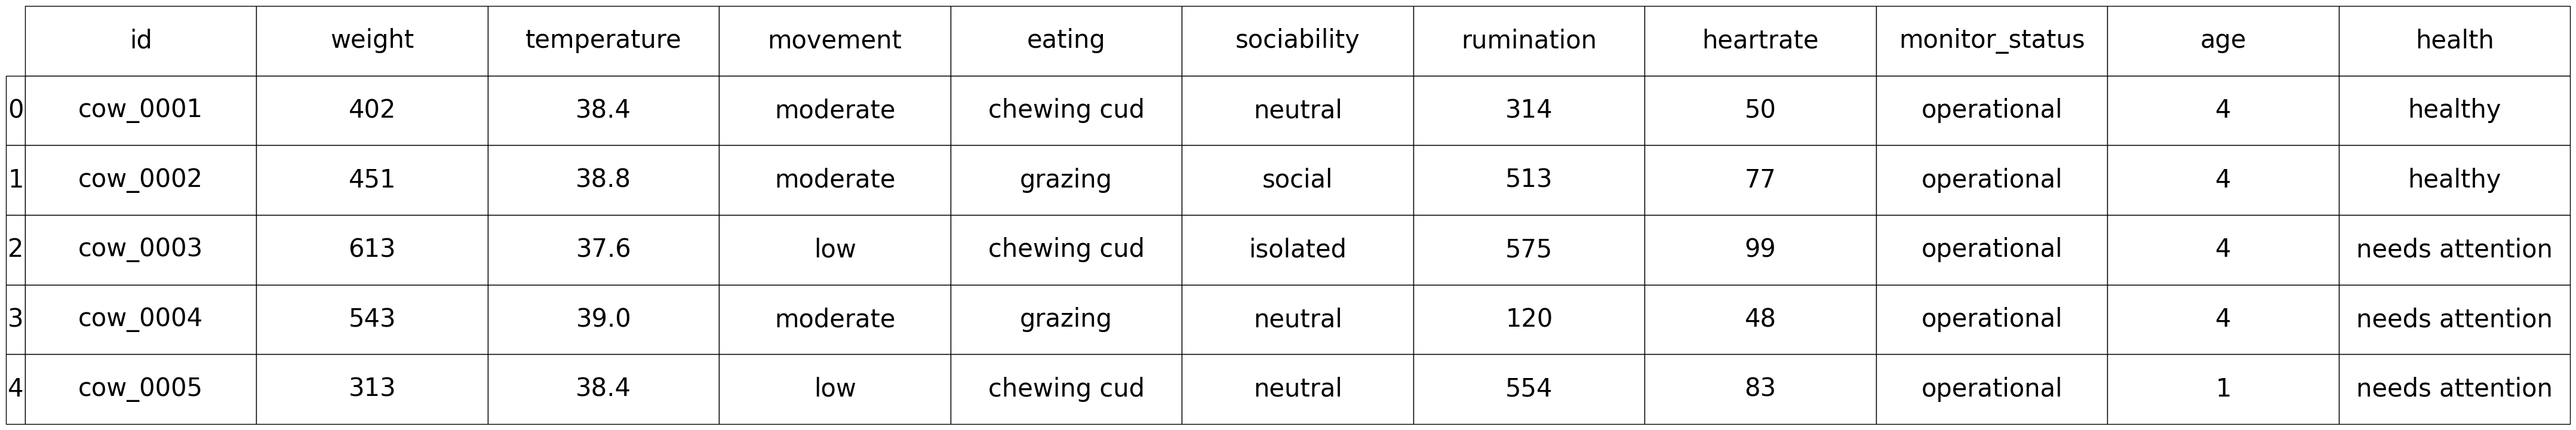

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# Load or use your existing DataFrame
df = pd.read_csv("fake_cow_dataset_binary_health.csv")
df_preview = df.head(5)

# Create a figure and axis
fig, ax = plt.subplots(figsize=(10, 4))  # Adjust size as needed
ax.axis('off')  # Hide axes

# Create table
table = pd.plotting.table(ax, df_preview, loc='center', cellLoc='center', colWidths=[0.1]*len(df_preview.columns))

# Style
table.auto_set_font_size(False)
table.set_fontsize(30)
table.scale(5, 7)  # Adjust row height/column width

# Save as image
plt.savefig("cow_data_preview5.png", bbox_inches='tight', dpi=300)
plt.show()
